In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import torch
import random
import numpy as np
from botorch.acquisition.analytic import AnalyticAcquisitionFunction
from botorch.utils.transforms import t_batch_mode_transform
from torch.distributions.normal import Normal
from models import RMILE
from utils import check_synthetic
import warnings
warnings.filterwarnings("ignore")

# Data

In [4]:
check_synthetic("levy10D", False)

Superlevel set percentage: 19.75%
Top 20%:  tensor(-76.3640)
0% tensor(-6.4312) tensor(-426.7236)
5% tensor(-2.7050) tensor(-218.7030)
10% tensor(-2.2463) tensor(-194.3655)
15% tensor(-1.9504) tensor(-178.5560)
20% tensor(-1.7153) tensor(-166.2271)
25% tensor(-1.5215) tensor(-155.8958)
30% tensor(-1.3483) tensor(-146.8922)
35% tensor(-1.1920) tensor(-138.7847)
40% tensor(-1.0489) tensor(-131.3727)
45% tensor(-0.9162) tensor(-124.3828)
50% tensor(-0.7875) tensor(-117.5905)
55% tensor(-0.6625) tensor(-110.9475)
60% tensor(-0.5394) tensor(-104.3319)
65% tensor(-0.4104) tensor(-97.5926)
70% tensor(-0.2809) tensor(-90.7555)
75% tensor(-0.1495) tensor(-83.7368)
80% tensor(-0.0073) tensor(-76.3640)
85% tensor(0.1404) tensor(-68.4674)
90% tensor(0.3112) tensor(-59.6043)
95% tensor(0.5327) tensor(-48.0085)


In [3]:
check_synthetic("ackley10D", False)

Superlevel set percentage: 20.0%
Top 20%:  tensor(-20.8627)
0% tensor(-2.9559) tensor(-22.1058)
5% tensor(-1.9339) tensor(-21.6803)
10% tensor(-1.7311) tensor(-21.5949)
15% tensor(-1.5817) tensor(-21.5322)
20% tensor(-1.4573) tensor(-21.4794)
25% tensor(-1.3453) tensor(-21.4316)
30% tensor(-1.2401) tensor(-21.3867)
35% tensor(-1.1356) tensor(-21.3433)
40% tensor(-1.0357) tensor(-21.3004)
45% tensor(-0.9362) tensor(-21.2572)
50% tensor(-0.8313) tensor(-21.2129)
55% tensor(-0.7217) tensor(-21.1668)
60% tensor(-0.6069) tensor(-21.1180)
65% tensor(-0.4814) tensor(-21.0654)
70% tensor(-0.3477) tensor(-21.0074)
75% tensor(-0.1908) tensor(-20.9412)
80% tensor(-7.1011e-05) tensor(-20.8627)
85% tensor(0.2362) tensor(-20.7640)
90% tensor(0.5583) tensor(-20.6267)
95% tensor(1.1269) tensor(-20.3882)


In [3]:
check_synthetic("alpine10D", False)

Superlevel set percentage: 19.92%
Top 20%:  tensor(-24.0269)
0% tensor(-5.7863) tensor(-69.5557)
5% tensor(-2.5938) tensor(-44.7878)
10% tensor(-2.1926) tensor(-41.5416)
15% tensor(-1.9147) tensor(-39.3780)
20% tensor(-1.7028) tensor(-37.6735)
25% tensor(-1.5255) tensor(-36.2308)
30% tensor(-1.3655) tensor(-34.9469)
35% tensor(-1.2199) tensor(-33.7719)
40% tensor(-1.0782) tensor(-32.6693)
45% tensor(-0.9474) tensor(-31.6109)
50% tensor(-0.8189) tensor(-30.5814)
55% tensor(-0.6929) tensor(-29.5671)
60% tensor(-0.5691) tensor(-28.5450)
65% tensor(-0.4408) tensor(-27.5014)
70% tensor(-0.3053) tensor(-26.4215)
75% tensor(-0.1599) tensor(-25.2760)
80% tensor(-0.0029) tensor(-24.0269)
85% tensor(0.1782) tensor(-22.6033)
90% tensor(0.3886) tensor(-20.8739)
95% tensor(0.6940) tensor(-18.4338)


# AA33

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
def load_deepperf_hippacc():
    df = pd.read_csv("HighdimLSE/deepperf_experiment/hipacc_AllNumeric.csv")
    y = df.iloc[:, -1].to_numpy()
    X = df.iloc[:, :-1].to_numpy()
    return X, y

In [3]:
X, y = load_deepperf_hippacc()
print(X.shape)
print(y.shape)

(13485, 33)
(13485,)


In [4]:
min_X = []
max_X = []
for i in range(X.shape[1]):
    min_X.append(X[:, i].min())
    max_X.append(X[:, i].max())
print(min_X)
print(max_X)

[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 4.0, 512.0]


In [5]:
np.quantile(y, 0.8)

45.1672

In [6]:
y.min(), y.max()

(21.173, 121.338)

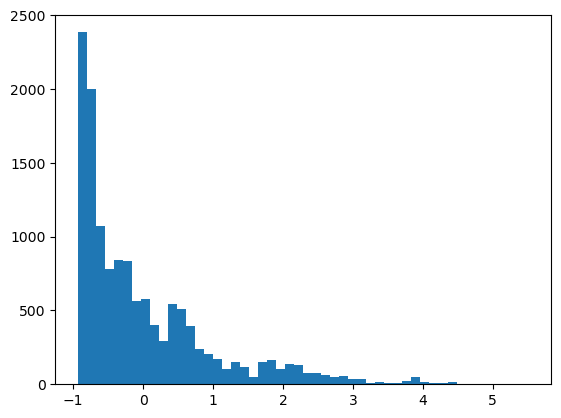

In [7]:
plt.hist((y - y.mean())/y.std(), 50)
plt.show()

In [8]:
y_standardized = (y - y.mean())/y.std()
print(np.quantile(y_standardized, 0.75))
print(np.quantile(y_standardized, 0.85))

0.4433104572872209
0.882064238684947


In [9]:
from dataloaders import fit_and_save_model, load_model, save_X
fit_and_save_model(X, y, "RealworldData/AlgorithmicAssurance/ground_truth.pkl")
save_X(X, "RealworldData/AlgorithmicAssurance")
model = load_model("RealworldData/AlgorithmicAssurance/ground_truth.pkl")

MSE:  0.32129822981202866


In [10]:
import torch
for i in np.random.randint(0, 10000, 100):
    print(model(torch.from_numpy(X[i, :].reshape(1, -1))), y[i])

tensor([40.8371], dtype=torch.float64) 41.352
tensor([29.8071], dtype=torch.float64) 29.471
tensor([22.6143], dtype=torch.float64) 22.422
tensor([23.3758], dtype=torch.float64) 23.467
tensor([31.5180], dtype=torch.float64) 31.426
tensor([31.5811], dtype=torch.float64) 31.694
tensor([32.1029], dtype=torch.float64) 33.406
tensor([28.4180], dtype=torch.float64) 28.135
tensor([36.3313], dtype=torch.float64) 38.454
tensor([22.6190], dtype=torch.float64) 22.583
tensor([25.6616], dtype=torch.float64) 25.631
tensor([22.3940], dtype=torch.float64) 22.445
tensor([22.4819], dtype=torch.float64) 22.701
tensor([36.4643], dtype=torch.float64) 35.303
tensor([21.7012], dtype=torch.float64) 21.68
tensor([27.6699], dtype=torch.float64) 27.644
tensor([21.7523], dtype=torch.float64) 21.68
tensor([34.3342], dtype=torch.float64) 34.193
tensor([23.7136], dtype=torch.float64) 23.689
tensor([28.4311], dtype=torch.float64) 28.705
tensor([30.5188], dtype=torch.float64) 30.318
tensor([23.0104], dtype=torch.float6

In [27]:
from dataloaders import DataLoader
from data_store import params
loader = DataLoader(params["AA33D"], False)

In [28]:
loader.raw_obj_func(torch.from_numpy(X[5].reshape(1, -1))), y[5]

(tensor([21.2038], dtype=torch.float64), 21.185)

In [29]:
loader.Xtest.shape

torch.Size([13485, 33])

In [30]:
loader.ytest.shape

torch.Size([13485])

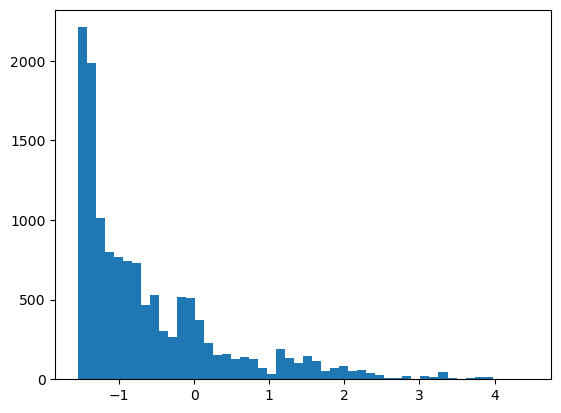

In [31]:
plt.hist(loader.ytest, 50)
plt.show()

# Protein

In [32]:
from dataloaders import data_generate_Protein
X, y = data_generate_Protein("HighdimLSE/Protein_data/Protein_data.csv")
print(X.shape, y.shape)

(796, 20) (796, 1)


In [33]:
print(X[:5])

[[26.  9. 11.  8. 22.  9. 15. 16. 10. 11. 12. 22. 23.  9. 10. 19.  6. 19.
  29.  7.]
 [14.  7.  8.  7. 19.  3. 12. 14.  8.  8. 15. 15. 22.  8.  8. 16.  5.  7.
  24.  7.]
 [19. 12.  9.  9. 13.  5. 14. 15.  6.  5. 11. 14. 16.  7.  6. 21.  6. 10.
  26.  3.]
 [19.  1.  7.  4. 23. 14. 11. 11. 10.  8. 11. 24. 26.  6.  1. 29.  1. 10.
  41.  1.]
 [27. 15. 11. 12. 25. 10. 17. 18. 11.  9. 20. 25. 31.  9.  9. 31. 10. 20.
  39.  7.]]


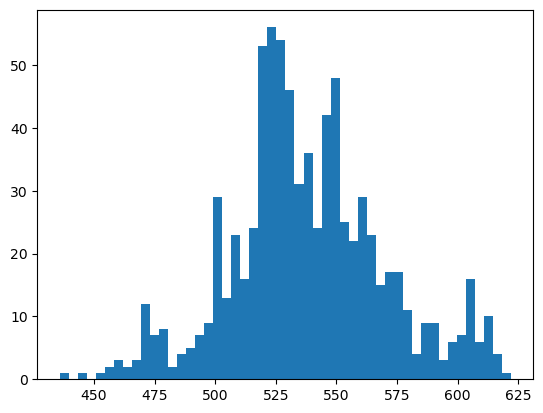

In [34]:
import matplotlib.pyplot as plt
plt.hist(y, 50)
plt.show()

In [36]:
from dataloaders import fit_and_save_model, save_X
fit_and_save_model(X, y.ravel(), "RealworldData/Protein/ground_truth.pkl")
save_X(X, "RealworldData/Protein")

MSE:  55.071876521693


In [37]:
min_X = []
max_X = []
for i in range(X.shape[1]):
    min_X.append(X[:, i].min())
    max_X.append(X[:, i].max())
print(min_X)
print(max_X)

[12.0, 1.0, 4.0, 1.0, 13.0, 3.0, 7.0, 5.0, 3.0, 3.0, 3.0, 8.0, 15.0, 4.0, 0.0, 13.0, 0.0, 2.0, 21.0, 0.0]
[33.0, 24.0, 14.0, 22.0, 37.0, 16.0, 20.0, 33.0, 17.0, 17.0, 31.0, 34.0, 33.0, 15.0, 15.0, 46.0, 18.0, 27.0, 46.0, 15.0]


In [38]:
import numpy as np
np.quantile(y, 0.8)

562.0

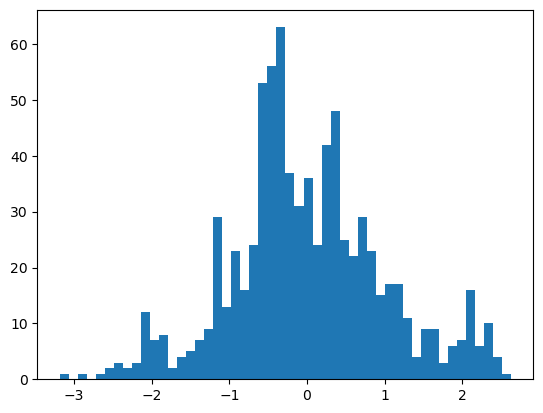

In [39]:
plt.hist((y - y.mean())/y.std(), 50)
plt.show()

In [40]:
y_standardized = (y - y.mean())/y.std()
print(np.quantile(y_standardized, 0.75))
print(np.quantile(y_standardized, 0.85))

0.5962173769813337
0.9937870326307128


In [41]:
from dataloaders import DataLoader
from data_store import params
loader = DataLoader(func_params=params["Protein20D"], grid=False)

In [42]:
loader.Xtest.shape

torch.Size([796, 20])

In [43]:
loader.ytest.shape

torch.Size([796])

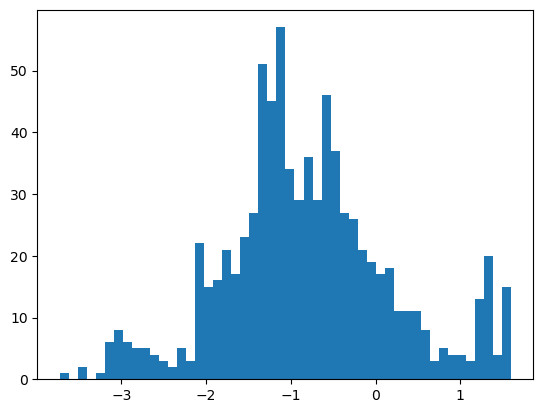

In [44]:
plt.hist(loader.ytest, 50)
plt.show()

In [45]:
import torch
loader.raw_obj_func(torch.from_numpy(X[712].reshape(1, -1))), y[712]

(tensor([575.4707], dtype=torch.float64), array([578], dtype=object))

# Ackley200D

In [1]:
from dataloaders import DataLoader
from data_store import params
loader = DataLoader(params["ackley200D"], False)

In [2]:
loader.Xtest.shape

torch.Size([2000000, 200])

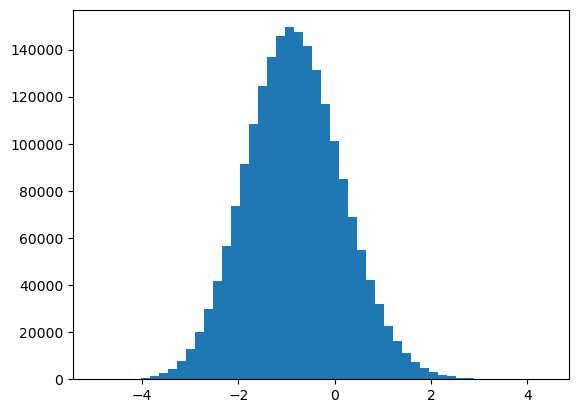

In [3]:
import matplotlib.pyplot as plt
plt.hist(loader.ytest, 50)
plt.show()

In [4]:
(loader.ytest > 0).sum()

tensor(400310)

# Levy100D

In [6]:
from dataloaders import DataLoader, denorm
from data_store import params
from utils import check_synthetic
import matplotlib.pyplot as plt
loader = DataLoader(params["levy100D"], False)

In [7]:
y = loader.raw_obj_func(denorm(loader.Xtest, loader.X_range))

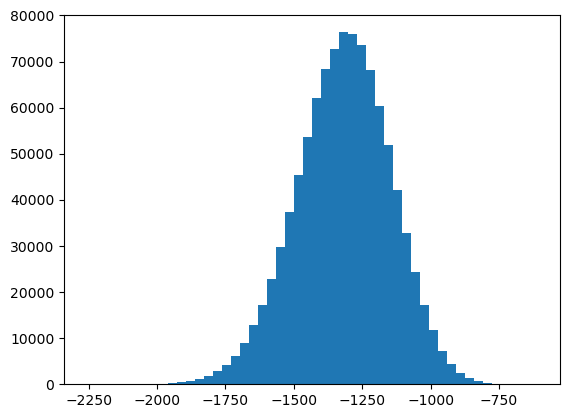

In [8]:
plt.hist(y, 50)
plt.show()

In [9]:
y.quantile(0.8)

tensor(-1171.4006)

In [5]:
check_synthetic("levy100D", False)

Superlevel set percentage: 20.0%
Top 20%:  tensor(-1171.3459)
0% tensor(-6.3313) tensor(-2164.2129)
5% tensor(-2.5495) tensor(-1609.4165)
10% tensor(-2.1540) tensor(-1541.4884)
15% tensor(-1.8908) tensor(-1496.3970)
20% tensor(-1.6836) tensor(-1460.9583)
25% tensor(-1.5087) tensor(-1430.8605)
30% tensor(-1.3545) tensor(-1404.1227)
35% tensor(-1.2097) tensor(-1379.5046)
40% tensor(-1.0752) tensor(-1356.2896)
45% tensor(-0.9460) tensor(-1334.0341)
50% tensor(-0.8194) tensor(-1312.3536)
55% tensor(-0.6935) tensor(-1290.8192)
60% tensor(-0.5671) tensor(-1269.0745)
65% tensor(-0.4375) tensor(-1246.8777)
70% tensor(-0.3034) tensor(-1223.6107)
75% tensor(-0.1579) tensor(-1198.7694)
80% tensor(-2.5295e-05) tensor(-1171.3459)
85% tensor(0.1818) tensor(-1139.8625)
90% tensor(0.4090) tensor(-1100.8235)
95% tensor(0.7349) tensor(-1044.4133)


# Rosenbrock100D

In [1]:
from dataloaders import DataLoader, denorm
from data_store import params
from utils import check_synthetic
import matplotlib.pyplot as plt
loader = DataLoader(params["rosen100D"], False)

tensor(-619.1880)


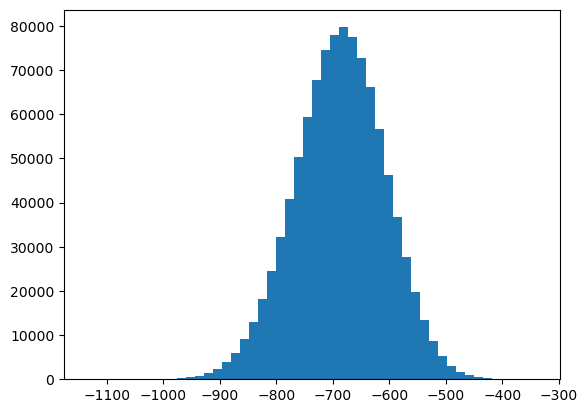

In [3]:
y = loader.raw_obj_func(denorm(loader.Xtest, loader.X_range))
print(y.quantile(0.8))
plt.hist(y, 50)
plt.show()

In [4]:
check_synthetic("rosen100D", False)

Superlevel set percentage: 20.02%
Top 20%:  tensor(-619.0425)
0% tensor(-5.8532)
5% tensor(-2.5292)
10% tensor(-2.1457)
15% tensor(-1.8872)
20% tensor(-1.6844)
25% tensor(-1.5120)
30% tensor(-1.3586)
35% tensor(-1.2161)
40% tensor(-1.0830)
45% tensor(-0.9543)
50% tensor(-0.8277)
55% tensor(-0.7030)
60% tensor(-0.5757)
65% tensor(-0.4456)
70% tensor(-0.3085)
75% tensor(-0.1610)
80% tensor(0.0008)
85% tensor(0.1883)
90% tensor(0.4200)
95% tensor(0.7588)


tensor(199591)


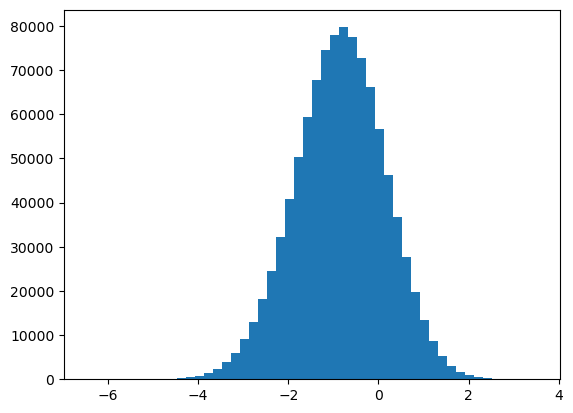

In [5]:
print((loader.ytest > 0).sum())
plt.hist(loader.ytest, 50)
plt.show()